# Notebook für Review "Historisiertes Gemeindeverzeichnis"

## Install/Import Modules

In [72]:
%pip install -q ipywidgets==8.0.4 ipycytoscape networkx nbformat plotly
import ipycytoscape as cy
import networkx as nx
import pandas as pd
import plotly.express as px
from ext.sparql import query, display_result

In [73]:
async def show_meta(URI, store):
    
    df = await query("""
    
    SELECT ?s1 ?p1 ?truc ?p2 ?o2
    FROM <https://lindas.admin.ch/fso/register>
    WHERE {

        BIND(<""" + URI + """> AS ?truc)
        {
            ?s1 ?p1 ?truc.
        }
        UNION
        {
            ?truc ?p2 ?o2.
        }

    }

    """, store)
    
    display_result(df)

# Datenmodell

## version.link

Die Daten zu den Gemeinden und Bezirken sind gemäss dem Schema https://version.link transformiert und in folgenden Namespaces zu finden:

- Gemeinden: `ld.admin.ch/municipality/` und `ld.admin.ch/municipality/version/`
- Bezirke: `ld.admin.ch/district/` und `ld.admin.ch/district/version/`
- Kantone: `ld.admin.ch/canton/` (es existieren keine Versionen zu den Kantonen)

## register.ld.admin.ch/agvch

Die Ursprungsdaten zum historisierten Gemeindeverzeichnis werden vom BFS als [eCH-0071 Standard](https://www.ech.ch/de/ech/ech-0071/1.1-0) gepflegt und als [XML Datei](https://www.bfs.admin.ch/bfs/de/home/grundlagen/agvch/historisiertes-gemeindeverzeichnis.assetdetail.23886070.html) veröffentlicht. Als direkte Linked Data Konversion existieren die Daten in folgenden Namespaces:

- Gemeinden: `register.ld.admin.ch/agvch/municipality/` und `register.ld.admin.ch/agvch/municipalityversion/`
- Bezirke: `register.ld.admin.ch/agvch/district/` und `register.ld.admin.ch/agvch/districtversion`
- Kantone: `register.ld.admin.ch/agvch/canton/` (es existieren keine Versionen zu den Kantonen)

# Identitäten (vl:Identity)

## Gemeinde

### Beispiel aktuelle Gemeinde: Bern

In [74]:
df = await query("""

PREFIX vl: <https://version.link/>

SELECT * 
FROM <https://lindas.admin.ch/fso/register>
WHERE {

    <https://ld.admin.ch/municipality/351> ?p ?o.

}


""", "https://test.lindas.admin.ch/query")

display_result(df)

,p,o
0,http://www.w3.org/1999/02/22-rdf-syntax-ns#type,https://schema.ld.admin.ch/Municipality
1,http://www.w3.org/1999/02/22-rdf-syntax-ns#type,https://schema.ld.admin.ch/PoliticalMunicipality
2,http://www.w3.org/1999/02/22-rdf-syntax-ns#type,https://version.link/Identity
3,http://schema.org/name,Bern
4,http://schema.org/identifier,351
5,http://schema.org/isPartOf,https://ld.admin.ch/district/246
6,http://schema.org/inDefinedTermSet,https://ld.admin.ch/dimension/municipality
7,https://version.link/version,https://ld.admin.ch/municipality/version/15029
8,https://version.link/inVersionedIdentitySet,https://ld.admin.ch/fso/register


Die Mandatory Properties aus version.link für eine Identität sind:

- OK: rdf:type vl:Identity
- OK: vl:version
- OK: vl:inVersionedIdentitySet
- OK: schema:identifier

Bern unter register.ld.admin.ch/agvch/municipality/351

In [75]:
df = await query("""

PREFIX vl: <https://version.link/>

SELECT * 
FROM <https://lindas.admin.ch/fso/register>
WHERE {

    <https://register.ld.admin.ch/agvch/municipality/351> ?p ?o.

}


""", "https://test.lindas.admin.ch/query")

display_result(df)

,p,o
0,http://www.w3.org/1999/02/22-rdf-syntax-ns#type,https://ld.admin.ch/ech/71/Municipality
1,http://schema.org/identifier,351
2,https://ld.admin.ch/ech/71/municipalityId,351
3,https://ld.admin.ch/ech/71/municipalityEntryModeId,11


### Beispiel nicht mehr aktuelle Gemeinde: Ennenda

In [76]:
df = await query("""

PREFIX vl: <https://version.link/>
PREFIX admin: <https://schema.ld.admin.ch/>

SELECT * 
FROM <https://lindas.admin.ch/fso/register>
WHERE {

    <https://ld.admin.ch/municipality/1607> ?p ?o.
}


""", "https://test.lindas.admin.ch/query")

display_result(df)

,p,o
0,http://www.w3.org/1999/02/22-rdf-syntax-ns#type,https://schema.ld.admin.ch/Municipality
1,http://www.w3.org/1999/02/22-rdf-syntax-ns#type,https://schema.ld.admin.ch/PoliticalMunicipality
2,http://www.w3.org/1999/02/22-rdf-syntax-ns#type,https://version.link/Identity
3,http://www.w3.org/1999/02/22-rdf-syntax-ns#type,https://version.link/Deprecated
4,http://schema.org/name,Ennenda
5,http://schema.org/identifier,1607
6,http://schema.org/isPartOf,https://ld.admin.ch/district/800
7,http://schema.org/inDefinedTermSet,https://ld.admin.ch/dimension/municipality
8,https://version.link/version,https://ld.admin.ch/municipality/version/12279
9,https://version.link/inVersionedIdentitySet,https://ld.admin.ch/fso/register


Die Mandatory Properties aus version.link für eine nicht mehr existierende Identität sind:

- OK: rdf:type vl:Identity
- OK: vl:version
- OK: vl:inVersionedIdentitySet
- OK: schema:identifier
- OK: vl:Deprecated

Ennenda unter register.ld.admin.ch/agvch/municipality/1607

In [77]:
df = await query("""

PREFIX vl: <https://version.link/>

SELECT * 
FROM <https://lindas.admin.ch/fso/register>
WHERE {

    <https://register.ld.admin.ch/agvch/municipality/1607> ?p ?o.

}


""", "https://test.lindas.admin.ch/query")

display_result(df)

,p,o
0,http://www.w3.org/1999/02/22-rdf-syntax-ns#type,https://ld.admin.ch/ech/71/Municipality
1,http://schema.org/identifier,1607
2,https://ld.admin.ch/ech/71/municipalityId,1607
3,https://ld.admin.ch/ech/71/municipalityEntryModeId,11


## Bezirk

### Beispiel aktueller Bezirk: Bern-Mittelland

In [78]:
df = await query("""

PREFIX vl: <https://version.link/>

SELECT * 
FROM <https://lindas.admin.ch/fso/register>
WHERE {

    <https://ld.admin.ch/district/246> ?p ?o.

}


""", "https://test.lindas.admin.ch/query")

display_result(df)

,p,o
0,http://www.w3.org/1999/02/22-rdf-syntax-ns#type,https://version.link/Identity
1,http://www.w3.org/1999/02/22-rdf-syntax-ns#type,https://schema.ld.admin.ch/District
2,http://schema.org/name,Bern-Mittelland
3,http://schema.org/identifier,246
4,http://schema.org/isPartOf,https://ld.admin.ch/canton/2
5,http://schema.org/inDefinedTermSet,https://ld.admin.ch/dimension/district
6,https://version.link/version,https://ld.admin.ch/district/version/10288
7,https://version.link/inVersionedIdentitySet,https://ld.admin.ch/fso/register


Die Mandatory Properties aus version.link für eine Identität sind:

- OK: rdf:type vl:Identity
- OK: vl:version
- OK: vl:inVersionedIdentitySet
- OK: schema:identifier

Bern-Mittelland unter register.ld.admin.ch/agvch/district/246

In [79]:
df = await query("""

PREFIX vl: <https://version.link/>

SELECT * 
FROM <https://lindas.admin.ch/fso/register>
WHERE {

    <https://register.ld.admin.ch/agvch/district/246> ?p ?o.

}


""", "https://test.lindas.admin.ch/query")

display_result(df)

,p,o
0,http://www.w3.org/1999/02/22-rdf-syntax-ns#type,https://ld.admin.ch/ech/71/District
1,http://schema.org/identifier,246
2,https://ld.admin.ch/ech/71/districtId,246
3,https://ld.admin.ch/ech/71/districtEntryModeId,15


### Beispiel nicht mehr aktueller Bezirk: Arbon

In [80]:
df = await query("""

PREFIX vl: <https://version.link/>
PREFIX admin: <https://schema.ld.admin.ch/>

SELECT * 
FROM <https://lindas.admin.ch/fso/register>
WHERE {

    <https://ld.admin.ch/district/2001> ?p ?o.
}


""", "https://test.lindas.admin.ch/query")

display_result(df)

,p,o
0,http://www.w3.org/1999/02/22-rdf-syntax-ns#type,https://version.link/Identity
1,http://www.w3.org/1999/02/22-rdf-syntax-ns#type,https://schema.ld.admin.ch/District
2,http://www.w3.org/1999/02/22-rdf-syntax-ns#type,https://version.link/Deprecated
3,http://schema.org/name,Arbon
4,http://schema.org/identifier,2001
5,http://schema.org/isPartOf,https://ld.admin.ch/canton/20
6,http://schema.org/inDefinedTermSet,https://ld.admin.ch/dimension/district
7,https://version.link/version,https://ld.admin.ch/district/version/10001
8,https://version.link/inVersionedIdentitySet,https://ld.admin.ch/fso/register


Arbon unter register.ld.admin.ch/agvch/district/2001

In [81]:
df = await query("""

PREFIX vl: <https://version.link/>

SELECT * 
FROM <https://lindas.admin.ch/fso/register>
WHERE {

    <https://register.ld.admin.ch/agvch/district/2001> ?p ?o.

}


""", "https://test.lindas.admin.ch/query")

display_result(df)

,p,o
0,http://www.w3.org/1999/02/22-rdf-syntax-ns#type,https://ld.admin.ch/ech/71/District
1,http://schema.org/identifier,2001
2,https://ld.admin.ch/ech/71/districtId,2001
3,https://ld.admin.ch/ech/71/districtEntryModeId,15


## Kanton

### Beispiel Kanton: Bern

In [82]:
df = await query("""

PREFIX vl: <https://version.link/>
PREFIX admin: <https://schema.ld.admin.ch/>
PREFIX schema: <http://schema.org/>

SELECT * 
FROM <https://lindas.admin.ch/fso/register>
WHERE {
    
    <https://ld.admin.ch/canton/2> ?p ?o.
}

""", "https://test.lindas.admin.ch/query")

display_result(df)

,p,o
0,http://www.w3.org/1999/02/22-rdf-syntax-ns#type,http://schema.org/DefinedTerm
1,http://www.w3.org/1999/02/22-rdf-syntax-ns#type,http://schema.org/AdministrativeArea
2,http://www.w3.org/1999/02/22-rdf-syntax-ns#type,https://schema.ld.admin.ch/Canton
3,http://www.w3.org/1999/02/22-rdf-syntax-ns#type,http://schema.org/State
4,http://www.w3.org/1999/02/22-rdf-syntax-ns#type,https://version.link/Identity
5,http://schema.org/name,Bern
6,http://schema.org/name,Berne
7,http://schema.org/name,Berna
8,http://schema.org/name,Bern
9,http://schema.org/identifier,2


Die Mandatory Properties aus version.link für eine Identität sind:

- OK: rdf:type vl:Identity
- NOK: vl:version --> Kantone sind nicht versioniert
- **NOK**: vl:inVersionedIdentitySet --> Gehört trotzdem zum Set dazu und sollte vorhanden sein
- OK: schema:identifier

## Hinweis zu vl:Deprecated

Wenn Identitäten, die nicht mehr existieren, wie in version.link vorgesehen, ein `rdf:type` `vl:Deprecated` hinzugefügt wird, entsteht das Problem, dass man in Queries explizit danach filtern muss, um nur die aktiven Gemeinden zu erhalten. 

version.link lässt jedoch offen, dass man zusätzliche Typen zuweist: Bspw. aktuellen Gemeinden ein `admin:Municipality` und nicht mehr aktuellen ein `admin:AbolishedMunicipality` (und kein `admin:Municipality` mehr). 

Somit könnte man einfacher nach allen aktiven Gemeinden suchen. Der Grund für die Einführung eines `vl:Deprecated`  sind die Versionen: Das Prinzip dort ist, dass man nichts ändern will, was man mal hinzugefügt hat. Man will also nicht, dass bspw. ein `vl:ActiveVersion` durch ein `vl:DeprecatedVersion` ersetzt wird, dieser Graph ist "strictly growing", man muss also ein `vl:Deprecated` anfügen, ohne etwas wegzunehmen. Damit bei den Identities der gleiche Mechanismus spielt, ist es dort auch so, aber in der Praxis könnte man immer zusätzlich zu `vl:Identity` als Typ auch etwas setzen, das man dann wenn die Identität abolished wird, weglässt und durch ein Spezifikum ersetzt.

## Queries zu Identitäten

### Anzahl aller Gemeinden

In [83]:
df = await query("""

PREFIX vl: <https://version.link/>
PREFIX admin: <https://schema.ld.admin.ch/>

SELECT (COUNT(*) AS ?count)
FROM <https://lindas.admin.ch/fso/register>
WHERE {

    ?muni a admin:PoliticalMunicipality.

}
""", "https://test.lindas.admin.ch/query")

display_result(df)

,count
0,3245


### Anzahl aller nicht mehr aktuellen Gemeinden

In [84]:
df = await query("""

PREFIX vl: <https://version.link/>
PREFIX admin: <https://schema.ld.admin.ch/>

SELECT (COUNT(*) AS ?count)
FROM <https://lindas.admin.ch/fso/register>
WHERE {

    ?muni a admin:PoliticalMunicipality;
        a vl:Deprecated.

}
""", "https://test.lindas.admin.ch/query")

display_result(df)

,count
0,1151


### Anzahl aller aktuellen Gemeinden

In [85]:
df = await query("""

PREFIX vl: <https://version.link/>
PREFIX admin: <https://schema.ld.admin.ch/>

SELECT (COUNT(*) AS ?count)
FROM <https://lindas.admin.ch/fso/register>
WHERE {

    ?muni a admin:PoliticalMunicipality;
    
    FILTER NOT EXISTS {?muni a vl:Deprecated}
    #MINUS {?muni a vl:Deprecated}

}
""", "https://test.lindas.admin.ch/query")

display_result(df)

,count
0,2094


### Anzahl aktueller Gemeinden pro Kanton

In [86]:
df = await query("""

PREFIX vl: <https://version.link/>
PREFIX admin: <https://schema.ld.admin.ch/>
PREFIX schema: <http://schema.org/>

SELECT ?canton ?cantonName ?numberOfMunies
FROM <https://lindas.admin.ch/fso/register>
WHERE {
    
    ?canton schema:legalName ?cantonName.

    {
        SELECT ?canton (COUNT(?muni) AS ?numberOfMunies)
        WHERE {

            ?muni a admin:PoliticalMunicipality;
                schema:isPartOf/schema:isPartOf ?canton.

            MINUS {?muni a vl:Deprecated}

        } GROUP BY ?canton
    
    }
} ORDER BY DESC(?numberOfMunies)

""", "https://test.lindas.admin.ch/query")

display_result(df)

,canton,cantonName,numberOfMunies
0,https://ld.admin.ch/canton/2,Bern / Berne,337
1,https://ld.admin.ch/canton/22,Vaud,297
2,https://ld.admin.ch/canton/19,Aargau,197
3,https://ld.admin.ch/canton/1,Zürich,160
4,https://ld.admin.ch/canton/23,Valais / Wallis,120
5,https://ld.admin.ch/canton/10,Fribourg / Freiburg,116
6,https://ld.admin.ch/canton/21,Ticino,105
7,https://ld.admin.ch/canton/11,Solothurn,104
8,https://ld.admin.ch/canton/18,Graubünden / Grigioni / Grischun,101
9,https://ld.admin.ch/canton/13,Basel-Landschaft,86


### Anzahl nicht mehr aktueller Gemeinden pro Kanton

In [87]:
df = await query("""

PREFIX vl: <https://version.link/>
PREFIX admin: <https://schema.ld.admin.ch/>
PREFIX schema: <http://schema.org/>

SELECT ?cantonName ?numberOfMunies
FROM <https://lindas.admin.ch/fso/register>
WHERE {
    
    ?canton schema:legalName ?cantonName.

    {
        SELECT ?canton (COUNT(?muni) AS ?numberOfMunies)
        WHERE {

            ?muni a admin:PoliticalMunicipality;
                schema:isPartOf/schema:isPartOf ?canton;
                a vl:Deprecated.

        } GROUP BY ?canton
    
    }
} ORDER BY DESC(?numberOfMunies)

""", "https://test.lindas.admin.ch/query")

display_result(df)

,cantonName,numberOfMunies
0,Fribourg / Freiburg,189
1,Ticino,167
2,Thurgau,158
3,Graubünden / Grigioni / Grischun,140
4,Vaud,106
5,Bern / Berne,76
6,Valais / Wallis,66
7,Aargau,44
8,Neuchâtel,40
9,Jura,39


### Anzahl aktueller Bezirke pro Kanton 

In [88]:
df = await query("""

PREFIX vl: <https://version.link/>
PREFIX admin: <https://schema.ld.admin.ch/>
PREFIX schema: <http://schema.org/>

SELECT ?cantonName ?numberOfDistricts
FROM <https://lindas.admin.ch/fso/register>
WHERE {
    
    ?canton schema:legalName ?cantonName.

    {
        SELECT ?canton (COUNT(?district) AS ?numberOfDistricts)
        WHERE {

            ?district a admin:District;
                schema:isPartOf ?canton.

            MINUS {?district a vl:Deprecated}

        } GROUP BY ?canton
    
    }
} ORDER BY DESC(?numberOfDistricts)

""", "https://test.lindas.admin.ch/query")

display_result(df)

,cantonName,numberOfDistricts
0,Valais / Wallis,14
1,Zürich,12
2,Aargau,12
3,Graubünden / Grigioni / Grischun,11
4,Vaud,11
5,Bern / Berne,11
6,Solothurn,10
7,St. Gallen,9
8,Ticino,9
9,Fribourg / Freiburg,8


# Versionen (vl:Version)

## Gemeinde

### Beispiel für eine Version einer Gemeinde: Klosters-Serneus

In [89]:
df = await query("""

PREFIX vl: <https://version.link/>
PREFIX admin: <https://schema.ld.admin.ch/>

SELECT * 
FROM <https://lindas.admin.ch/fso/register>
WHERE {

    <https://ld.admin.ch/municipality/version/14310> ?p ?o.
}


""", "https://test.lindas.admin.ch/query")

display_result(df)

,p,o
0,http://www.w3.org/1999/02/22-rdf-syntax-ns#type,http://schema.org/DefinedTerm
1,http://www.w3.org/1999/02/22-rdf-syntax-ns#type,https://version.link/Version
2,http://schema.org/name,Klosters-Serneus
3,http://schema.org/identifier,14310
4,http://schema.org/isPartOf,https://ld.admin.ch/district/version/10258
5,http://schema.org/validFrom,2001-01-01
6,http://www.geonames.org/ontology#featureCode,http://www.geonames.org/ontology#A.ADM3
7,http://schema.org/validThrough,2015-12-31
8,http://schema.org/endDate,2015-12-31
9,http://schema.org/legalName,Klosters-Serneus


Die Mandatory Properties aus version.link für eine Version sind:

- OK: rdf:type vl:Version
- OK: vl:identity
- OK: vl:identityIdentifier
- OK: vl:inVersionedIdentitySet
- OK: schema:identifier
- OK: vl:predecessor
- OK: vl:successor

**Die Version der Gemeinde zeigt auf eine Version des Districts, version.link verlangt hier aber eigentlich der Link auf die Identität des Bezirks** --> nochmals darüber nachdenken

Wenn es so gemacht wird wie aktuell (und nicht wie in version.link vorgesehen), heisst das, dass es Versionen von Gemeinden gibt, die nicht mehr aktuell sind, die aber auf eine Version eines Districts zeigen, der noch aktuell ist...

Klosters-Serneus unter register.ld.admin.ch/agvch/municipalityversion/14310

In [90]:
df = await query("""

PREFIX vl: <https://version.link/>
PREFIX admin: <https://schema.ld.admin.ch/>

SELECT * 
FROM <https://lindas.admin.ch/fso/register>
WHERE {

    <https://register.ld.admin.ch/agvch/municipalityversion/14310> ?p ?o.
}


""", "https://test.lindas.admin.ch/query")

display_result(df)

,p,o
0,http://www.w3.org/1999/02/22-rdf-syntax-ns#type,https://ld.admin.ch/ech/71/MunicipalityVersion
1,http://schema.org/name,Klosters-Serneus
2,http://schema.org/identifier,14310
3,http://schema.org/legalName,Klosters-Serneus
4,https://ld.admin.ch/ech/71/cantonAbbreviation,GR
5,https://ld.admin.ch/ech/71/shortName,Klosters-Serneus
6,https://ld.admin.ch/ech/71/districtHistId,10258
7,https://ld.admin.ch/ech/71/municipalityId,3871
8,https://ld.admin.ch/ech/71/municipalityStatusId,1
9,https://ld.admin.ch/ech/71/municipalityAdmissionNumber,2110


## Bezirk

### Beispiel für eine Version eines Bezirks: Diessenhofen

In [91]:
df = await query("""

PREFIX vl: <https://version.link/>
PREFIX admin: <https://schema.ld.admin.ch/>

SELECT * 
FROM <https://lindas.admin.ch/fso/register>
WHERE {

    <https://ld.admin.ch/district/version/10027> ?p ?o.
}


""", "https://test.lindas.admin.ch/query")

display_result(df)

,p,o
0,http://www.w3.org/1999/02/22-rdf-syntax-ns#type,http://schema.org/DefinedTerm
1,http://www.w3.org/1999/02/22-rdf-syntax-ns#type,https://version.link/Version
2,http://schema.org/name,Diessenhofen
3,http://schema.org/identifier,10027
4,http://schema.org/isPartOf,https://ld.admin.ch/canton/20
5,http://www.geonames.org/ontology#featureCode,http://www.geonames.org/ontology#A.ADM2
6,http://schema.org/containedInPlace,https://ld.admin.ch/canton/20
7,http://schema.org/endDate,2010-12-31
8,http://schema.org/legalName,Bezirk Diessenhofen
9,http://schema.org/startDate,1960-01-01


Die Mandatory Properties aus version.link für eine Version sind:

- OK: rdf:type vl:Version
- OK: vl:identity
- OK: vl:identityIdentifier
- OK: vl:inVersionedIdentitySet
- OK: schema:identifier
- OK: vl:successor
- OK: vl:predecessor (hier nicht anwendbar)

Diessenhofen unter register.ld.admin.ch/agvch/districtversion/10027

In [92]:
df = await query("""

PREFIX vl: <https://version.link/>
PREFIX admin: <https://schema.ld.admin.ch/>

SELECT * 
FROM <https://lindas.admin.ch/fso/register>
WHERE {

    <https://register.ld.admin.ch/agvch/districtversion/10027> ?p ?o.
}


""", "https://test.lindas.admin.ch/query")

display_result(df)

,p,o
0,http://www.w3.org/1999/02/22-rdf-syntax-ns#type,https://ld.admin.ch/ech/71/DistrictVersion
1,http://schema.org/name,Diessenhofen
2,http://schema.org/identifier,10027
3,http://schema.org/legalName,Bezirk Diessenhofen
4,https://ld.admin.ch/ech/71/cantonId,20
5,https://ld.admin.ch/ech/71/districtId,2003
6,https://ld.admin.ch/ech/71/shortName,Diessenhofen
7,https://ld.admin.ch/ech/71/districtHistId,10027
8,https://ld.admin.ch/ech/71/longName,Bezirk Diessenhofen
9,https://ld.admin.ch/ech/71/districtAdmissionNumber,100


## Spezielle Versionen von Gemeinden

Es gibt Versionen von Gemeinden, die gar keine Gemeinden sind, das sind gemeindefreie Gebiete und kantonale Seeanteile. Nachfolgende Query vergleicht zwei verschiedene Sets, wie man zu diesen Gemeinden kommt, einmal Filterung über die "municipalityEntryModeId" aus den AGVCH Daten und einmal darüber, dass die Version keine Identität hat, die vom Typ `admin:Municipality` resp. `admin:District` ist. --> Wieso unterscheiden sich diese zwei Listen?

In [93]:
df = await query("""

PREFIX vl: <https://version.link/>
PREFIX admin: <https://schema.ld.admin.ch/>
PREFIX schema: <http://schema.org/>

SELECT ?version ?name ?identityName
FROM <https://lindas.admin.ch/fso/register>
WHERE {

    ?version a vl:Version;
        schema:name ?name;
        vl:identity ?identity;
        <http://www.w3.org/ns/prov#hadPrimarySource> ?versionAGVCH.
    ?identity schema:name ?identityName.
    ?versionAGVCH <https://ld.admin.ch/ech/71/municipalityEntryModeId> ?entryMode.
    
    FILTER(?entryMode != 11)
    
    MINUS {
    
        ?version a vl:Version;
            vl:identity ?identity;
            schema:name ?name.
    
        FILTER NOT EXISTS {?identity a admin:Municipality}
        FILTER NOT EXISTS {?identity a admin:District}
    
    }
        


} ORDER BY ?name

""", "https://test.lindas.admin.ch/query")

display_result(df)

,version,name,identityName
0,https://ld.admin.ch/municipality/version/14359,C'za Bid./Capri./Cortic.,Collina d'Oro
1,https://ld.admin.ch/municipality/version/11250,C'za Bid./Sala C./Corti.,Collina d'Oro
2,https://ld.admin.ch/municipality/version/14358,C'za Capriasca/Lugagg.,Alto Malcantone
3,https://ld.admin.ch/municipality/version/10302,C'za Corticiasca/Valcol.,Monteceneri
4,https://ld.admin.ch/municipality/version/11251,C'za Sala C./Vag./Lugag.,Alto Malcantone
5,https://ld.admin.ch/municipality/version/11252,G.-geb. Maienfeld-Fläsch,Landquart


## Test vl:Deprecated auf letzter Version

Laut Anforderungen von version.link, muss im Falle, dass eine Identität vl:Deprecated erhält, die letzte Version ebenfall ein vl:Deprecated haben:

In [94]:
df = await query("""

PREFIX vl: <https://version.link/>
PREFIX admin: <https://schema.ld.admin.ch/>

SELECT *
FROM <https://lindas.admin.ch/fso/register>
WHERE {

    ?muni a admin:PoliticalMunicipality;
        a vl:Deprecated;
        vl:version ?version.
    ?version a vl:Deprecated.
        
    #MINUS {?version a vl:Deprecated}

} LIMIT 10

""", "https://test.lindas.admin.ch/query")

display_result(df)

,muni,version


Scheinbar haben diese Versionen alle nicht ein vl:Deprecated..., gibt es überhaupt vl:Version mit vl:Deprecated:

In [95]:
df = await query("""

PREFIX vl: <https://version.link/>
PREFIX admin: <https://schema.ld.admin.ch/>

SELECT *
FROM <https://lindas.admin.ch/fso/register>
WHERE {

    ?version a vl:Version;
        vl:identity ?muni;
        a vl:Deprecated.
    ?muni a admin:PoliticalMunicipality

} LIMIT 10

""", "https://test.lindas.admin.ch/query")

display_result(df)

,version,muni


es gibt keine Versionen mit vl:Deprecated

## Wiederauferstandene Gemeinden

Gibt es Gemeinden, deren Identität nicht lückenlos bestanden hat (Wiederauferstehung):

In [96]:
df = await query("""

PREFIX vl: <https://version.link/>
PREFIX admin: <https://schema.ld.admin.ch/>
PREFIX schema: <http://schema.org/>

SELECT *
FROM <https://lindas.admin.ch/fso/register>
WHERE {

    {
        SELECT ?muniIdentity (COUNT(?startEvent) AS ?count)
        WHERE {

            ?muniIdentity a vl:Identity;
                a admin:Municipality.
            ?muniVersion vl:identity ?muniIdentity;
                vl:startEvent ?startEvent.
            ?startEvent a vl:InitialRecording.
        } GROUP BY ?muniIdentity
    }
    FILTER(?count != 1)
}


""", "https://test.lindas.admin.ch/query")

display_result(df)

,muniIdentity,count


Es gibt keine wiederauferstandenen Gemeinden, also zumindest nicht mit mehreren vl:InitialRecording. Etwas anders sieht es aus, wenn das keine Anforderung für Wiederauferstehung ist, siehe [hier](#Zeitstrahl-von-Versionen-(Berg-(TG))).

# Veränderungsprozesse

## Gemeinden zu einem bestimmten Zeitpunkt in einem Kanton

In [97]:
df = await query("""

PREFIX vl: <https://version.link/>
PREFIX admin: <https://schema.ld.admin.ch/>
PREFIX schema: <http://schema.org/>
PREFIX xsd: <http://www.w3.org/2001/XMLSchema#>

SELECT ?date ?muniVersion ?name
FROM <https://lindas.admin.ch/fso/register>
WHERE {

    BIND ("2000-01-01"^^xsd:date AS ?date)
    
    ?muniVersion a vl:Version;
        vl:identity ?muni;
        schema:isPartOf/schema:isPartOf <https://ld.admin.ch/canton/8>;
        schema:startDate ?start;
        schema:legalName ?name.
    ?muni a admin:PoliticalMunicipality.
        
    OPTIONAL {?muniVersion schema:endDate ?stop.}
    
    BIND (IF(BOUND(?stop), ?stop, ?date) AS ?stop2)
    
    FILTER (?date >= ?start)
    FILTER (?date <= ?stop2)

}

""", "https://test.ld.admin.ch/query")

display_result(df)

,date,muniVersion,name
0,2000-01-01,https://ld.admin.ch/municipality/version/10413,Sool
1,2000-01-01,https://ld.admin.ch/municipality/version/11971,Hätzingen
2,2000-01-01,https://ld.admin.ch/municipality/version/11981,Haslen
3,2000-01-01,https://ld.admin.ch/municipality/version/12011,Filzbach
4,2000-01-01,https://ld.admin.ch/municipality/version/12070,Glarus
5,2000-01-01,https://ld.admin.ch/municipality/version/12232,Elm
6,2000-01-01,https://ld.admin.ch/municipality/version/12279,Ennenda
7,2000-01-01,https://ld.admin.ch/municipality/version/12285,Engi
8,2000-01-01,https://ld.admin.ch/municipality/version/12352,Mühlehorn
9,2000-01-01,https://ld.admin.ch/municipality/version/12418,Mitlödi


## Beispiel für Versionsgeschichte Fusion: Klosters

Welche Gemeinden spielten alle eine Rolle bei der heutigen Gemeinde "Klosters" (BFS Nummer 3871)?

In [98]:
df = await query("""

PREFIX vl: <https://version.link/>
PREFIX admin: <https://schema.ld.admin.ch/>
PREFIX schema: <http://schema.org/>

SELECT ?participants ?name
FROM <https://lindas.admin.ch/fso/register>
WHERE {

    <https://ld.admin.ch/municipality/3871> vl:version ?final.
    ?participants vl:successor* ?final;
        schema:name ?name.
    
    MINUS {?participants a vl:ChangeEvent}
}


""", "https://test.lindas.admin.ch/query")

display_result(df)

,participants,name
0,https://ld.admin.ch/municipality/version/10155,Saas
1,https://ld.admin.ch/municipality/version/11299,Klosters
2,https://ld.admin.ch/municipality/version/13233,Klosters-Serneus
3,https://ld.admin.ch/municipality/version/14310,Klosters-Serneus
4,https://ld.admin.ch/municipality/version/14313,Saas
5,https://ld.admin.ch/municipality/version/16070,Klosters-Serneus
6,https://ld.admin.ch/municipality/version/16610,Klosters
7,https://ld.admin.ch/municipality/version/15682,Klosters-Serneus


Grafische Darstellung

In [99]:
df = await query("""

PREFIX vl: <https://version.link/>
PREFIX admin: <https://schema.ld.admin.ch/>
PREFIX schema: <http://schema.org/>

SELECT ?source ?target
FROM <https://lindas.admin.ch/fso/register>
WHERE {

    <https://ld.admin.ch/municipality/3871> vl:version ?final.
    ?source vl:successor* ?final;
        vl:successor ?target.
    
    MINUS {?source a vl:ChangeEvent}
}


""", "https://test.lindas.admin.ch/query")


G = nx.from_pandas_edgelist(df, create_using=nx.DiGraph())

my_style = [
    {
        'selector': 'node',
         'style': {
            'font-family': 'helvetica',
            'font-size': '8px',
            'label': 'data(id)'
         }
    },
    {
        "selector": "edge.directed",
        "style": {
            "curve-style": "bezier",
            "target-arrow-shape": "triangle",
        }
    }
]

muni = cy.CytoscapeWidget()
muni.graph.add_graph_from_networkx(G, directed=True)
muni.set_style(my_style)
muni.set_layout(name = "dagre", rankDir = "LR")
muni

CytoscapeWidget(cytoscape_layout={'name': 'dagre', 'rankDir': 'LR'}, cytoscape_style=[{'selector': 'node', 'st…

## Beispiel für Versionsgeschichte Teilung: Bolligen

Für Bolligen (BFS Nummer 352) als Beispiel für eine Gemeinde, die sich geteilt hat:

In [100]:
df = await query("""

PREFIX vl: <https://version.link/>
PREFIX admin: <https://schema.ld.admin.ch/>
PREFIX schema: <http://schema.org/>

SELECT ?source ?target
FROM <https://lindas.admin.ch/fso/register>
WHERE {

    <https://ld.admin.ch/municipality/352> vl:version ?final.
    ?source vl:successor* ?final;
        vl:successor ?target;
        schema:name ?sourceName.
    ?target schema:name ?targetName.
    
    MINUS {?source a vl:ChangeEvent}
}


""", "https://test.lindas.admin.ch/query")


G = nx.from_pandas_edgelist(df, source="source", target="target", create_using=nx.DiGraph())

my_style = [
    {
        'selector': 'node',
         'style': {
            'font-family': 'helvetica',
            'font-size': '8px',
            'label': 'data(id)'
         }
    },
    {
        "selector": "edge.directed",
        "style": {
            "curve-style": "bezier",
            "target-arrow-shape": "triangle",
        }
    }
]

muni = cy.CytoscapeWidget()
muni.graph.add_graph_from_networkx(G, directed=True)
muni.set_style(my_style)
muni.set_layout(name = "dagre", rankDir = "LR")
muni

CytoscapeWidget(cytoscape_layout={'name': 'dagre', 'rankDir': 'LR'}, cytoscape_style=[{'selector': 'node', 'st…

## Alle Gemeinden, die sich geteilt haben

In [101]:
df = await query("""

PREFIX vl: <https://version.link/>
PREFIX admin: <https://schema.ld.admin.ch/>
PREFIX schema: <http://schema.org/>

SELECT * 
FROM <https://lindas.admin.ch/fso/register>
WHERE {
    
    ?source schema:name ?name
    
    {
        SELECT ?source (COUNT(?target) as ?successors)
        WHERE {

            ?source vl:successor ?target;

            MINUS {?source a vl:ChangeEvent}
            
            FILTER(regex(str(?source), "municipality" ) )
        } 
        GROUP BY ?source
    }
    FILTER(?successors > 1)
}

""", "https://test.lindas.admin.ch/query")

display_result(df)

,source,name,successors
0,https://ld.admin.ch/municipality/version/10790,Maienfeld,2
1,https://ld.admin.ch/municipality/version/10792,Fläsch,2
2,https://ld.admin.ch/municipality/version/12036,Gottshaus,2
3,https://ld.admin.ch/municipality/version/12346,Monte,2
4,https://ld.admin.ch/municipality/version/11252,G.-geb. Maienfeld-Fläsch,2
5,https://ld.admin.ch/municipality/version/12481,Opfershofen (TG),2
6,https://ld.admin.ch/municipality/version/11296,Bolligen,3
7,https://ld.admin.ch/municipality/version/12538,Neftenbach,2
8,https://ld.admin.ch/municipality/version/11320,Arni-Islisberg,2
9,https://ld.admin.ch/municipality/version/12612,Lavertezzo,3


Problem: Wenn man nicht dir URI filtert, sind da auch Districts dabei und nicht nur Municipalities, es ist schwierig, nur nach Versionen von Gemeinden zu suchen --> sollte man wohl noch was anhängen admin:MunicipalityVersion

## Analyse Berg (TG)

Dies ist ein Beispiel für eine Abfrage, wo zu Beginn oder am Ende nicht eine einzelne Version steht, sondern man von einer Version in der "Mitte" des Geschehens ausgeht. Zusätzlich sollen nicht mehr nur die URI der Versionen in der Grafik angezeigt werden, sondern die Namen, dafür muss man Node Attribute generieren (man kann nicht einfach nur auf die Namen setzten, weil die sind ja nicht eindeutig).

In [102]:
edge_df = await query("""

PREFIX vl: <https://version.link/>
PREFIX admin: <https://schema.ld.admin.ch/>
PREFIX schema: <http://schema.org/>

SELECT ?source ?target ?sourceName ?targetName
FROM <https://lindas.admin.ch/fso/register>
WHERE {
    
    {
        <https://ld.admin.ch/municipality/version/14062> vl:predecessor* ?target.
        ?target vl:predecessor ?source;
            schema:name ?targetName.
        ?source schema:name ?sourceName.
    }
    UNION
    {
        <https://ld.admin.ch/municipality/version/14062> vl:successor* ?source.
        ?source vl:successor ?target;
            schema:name ?sourceName.
        ?target schema:name ?targetName.
    }
}

""", "https://test.lindas.admin.ch/query")

ids = pd.Series.tolist(edge_df["source"]) + pd.Series.tolist(edge_df["target"])
names = pd.Series.tolist(edge_df["sourceName"]) + pd.Series.tolist(edge_df["targetName"])

node_df = pd.DataFrame(list(zip(ids, names)), columns = ["id", "name"])
node_df.drop_duplicates(inplace=True)

G = nx.from_pandas_edgelist(edge_df, source="source", target="target", create_using=nx.DiGraph())
nx.set_node_attributes(G, node_df.set_index('id').to_dict('index'))


my_style = [
    {
        'selector': 'node',
         'style': {
            'font-family': 'helvetica',
            'font-size': '12px',
            'label': 'data(name)'
         }
    },
    {
        "selector": "edge.directed",
        "style": {
            "curve-style": "bezier",
            "target-arrow-shape": "triangle",
        }
    }
]

muni = cy.CytoscapeWidget()
muni.graph.add_graph_from_networkx(G, directed=True)
muni.set_style(my_style)
muni.set_layout(name = "dagre", rankDir = "LR")
muni

CytoscapeWidget(cytoscape_layout={'name': 'dagre', 'rankDir': 'LR'}, cytoscape_style=[{'selector': 'node', 'st…

## Zeitstrahl von Versionen: Berg (TG)

,version,Start,Stop2
0,https://ld.admin.ch/municipality/version/11761,1960-01-01,1992-12-31
1,https://ld.admin.ch/municipality/version/14062,1994-12-31,1994-12-31
2,https://ld.admin.ch/municipality/version/14063,1995-01-01,1997-12-31
3,https://ld.admin.ch/municipality/version/14112,1998-01-01,2010-12-31
4,https://ld.admin.ch/municipality/version/15461,2011-01-01,2023-04-01


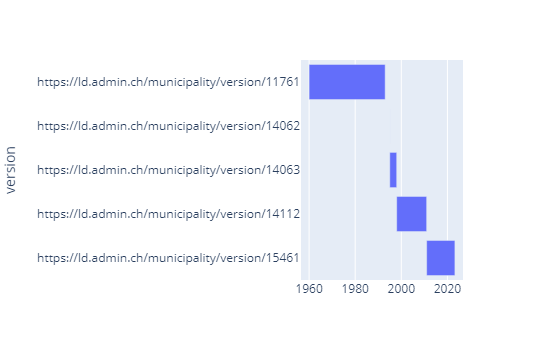

In [103]:
df = await query("""

PREFIX vl: <https://version.link/>
PREFIX admin: <https://schema.ld.admin.ch/>
PREFIX schema: <http://schema.org/>
PREFIX xsd: <http://www.w3.org/2001/XMLSchema#>

SELECT ?version ?Start ?Stop2
FROM <https://lindas.admin.ch/fso/register>
WHERE {

    ?version vl:identity <https://ld.admin.ch/municipality/4891>;
        schema:startDate ?Start.
        OPTIONAL {?version schema:endDate ?Stop}
        
        BIND ("2023-04-01"^^xsd:date AS ?today).
        
        BIND (IF(BOUND(?Stop), ?Stop, ?today) AS ?Stop2).
    
}


""", "https://test.lindas.admin.ch/query")

display_result(df)

fig = px.timeline(df, x_start="Start", x_end="Stop2", y="version")
fig.update_yaxes(autorange="reversed") # otherwise tasks are listed from the bottom up
fig.show()

Interessante Geschichte: Einerseits gibt es eine Lücke in der Identität nach 11761, andererseits hat man eine Version, die nur an einem Tag existiert (14062).

## Versionen, die ohne Zeitausdehnung existieren

In [104]:
df = await query("""

PREFIX vl: <https://version.link/>
PREFIX admin: <https://schema.ld.admin.ch/>
PREFIX schema: <http://schema.org/>
PREFIX xsd: <http://www.w3.org/2001/XMLSchema#>

SELECT *
FROM <https://lindas.admin.ch/fso/register>
WHERE {

    ?version a vl:Version;
        schema:name ?name;
        schema:startDate ?start;
        schema:endDate ?stop.
        
    FILTER(?start = ?stop)
    
}


""", "https://test.lindas.admin.ch/query")

display_result(df)

,version,name,start,stop
0,https://ld.admin.ch/municipality/version/14050,Opfershofen (TG),1994-12-31,1994-12-31
1,https://ld.admin.ch/municipality/version/14061,Weinfelden,1994-12-31,1994-12-31
2,https://ld.admin.ch/municipality/version/14062,Berg (TG),1994-12-31,1994-12-31
3,https://ld.admin.ch/municipality/version/14070,Wittenwil,1995-12-31,1995-12-31
4,https://ld.admin.ch/municipality/version/14076,Gottshaus,1995-12-31,1995-12-31
5,https://ld.admin.ch/municipality/version/14077,Bischofszell,1995-12-31,1995-12-31
6,https://ld.admin.ch/municipality/version/14080,Bischofszell,1995-12-31,1995-12-31
7,https://ld.admin.ch/municipality/version/14081,Kradolf-Schönenberg,1995-12-31,1995-12-31
8,https://ld.admin.ch/municipality/version/14091,Eschlikon,1996-12-31,1996-12-31
9,https://ld.admin.ch/municipality/version/14092,Sirnach,1996-12-31,1996-12-31


In [105]:
df = await query("""

PREFIX vl: <https://version.link/>
PREFIX admin: <https://schema.ld.admin.ch/>
PREFIX schema: <http://schema.org/>
PREFIX xsd: <http://www.w3.org/2001/XMLSchema#>

SELECT ?predecessor ?predecessorAbolitionMode ?admissionMode ?version ?abolitionMode ?successorAdmissionMode ?successor
FROM <https://lindas.admin.ch/fso/register>
WHERE {

    ?version a vl:Version;
        schema:name ?name;
        schema:startDate ?start;
        schema:endDate ?stop;
        vl:predecessor ?predecessor;
        vl:successor ?successor.
        
    ?version <http://www.w3.org/ns/prov#hadPrimarySource> ?versionAGVCH.
    ?predecessor <http://www.w3.org/ns/prov#hadPrimarySource> ?predecessorAGVCH.
    ?successor <http://www.w3.org/ns/prov#hadPrimarySource> ?successorAGVCH.
            
    ?predecessorAGVCH <https://ld.admin.ch/ech/71/municipalityAbolitionModeId> ?predecessorAbolitionMode.
    ?versionAGVCH <https://ld.admin.ch/ech/71/municipalityAdmissionModeId> ?admissionMode.
    ?versionAGVCH <https://ld.admin.ch/ech/71/municipalityAbolitionModeId> ?abolitionMode.
    ?successorAGVCH <https://ld.admin.ch/ech/71/municipalityAdmissionModeId> ?successorAdmissionMode.

    #MINUS {?predecessor a vl:ChangeEvent}
    #MINUS {?successor a vl:ChangeEvent}
        
    FILTER(?start = ?stop)
    
} ORDER BY ?version


""", "https://test.lindas.admin.ch/query")

display_result(df)

,predecessor,predecessorAbolitionMode,admissionMode,version,abolitionMode,successorAdmissionMode,successor
0,https://ld.admin.ch/municipality/version/12481,26,26,https://ld.admin.ch/municipality/version/14050,29,26,https://ld.admin.ch/municipality/version/14052
1,https://ld.admin.ch/municipality/version/13199,26,26,https://ld.admin.ch/municipality/version/14050,29,26,https://ld.admin.ch/municipality/version/14052
2,https://ld.admin.ch/municipality/version/10449,26,26,https://ld.admin.ch/municipality/version/14061,26,26,https://ld.admin.ch/municipality/version/14064
3,https://ld.admin.ch/municipality/version/10445,29,26,https://ld.admin.ch/municipality/version/14061,26,26,https://ld.admin.ch/municipality/version/14064
4,https://ld.admin.ch/municipality/version/10445,29,26,https://ld.admin.ch/municipality/version/14061,26,26,https://ld.admin.ch/municipality/version/14063
5,https://ld.admin.ch/municipality/version/10449,26,26,https://ld.admin.ch/municipality/version/14061,26,26,https://ld.admin.ch/municipality/version/14063
6,https://ld.admin.ch/municipality/version/12041,29,26,https://ld.admin.ch/municipality/version/14062,26,26,https://ld.admin.ch/municipality/version/14064
7,https://ld.admin.ch/municipality/version/13753,26,26,https://ld.admin.ch/municipality/version/14062,26,26,https://ld.admin.ch/municipality/version/14064
8,https://ld.admin.ch/municipality/version/11930,29,26,https://ld.admin.ch/municipality/version/14062,26,26,https://ld.admin.ch/municipality/version/14064
9,https://ld.admin.ch/municipality/version/12401,29,26,https://ld.admin.ch/municipality/version/14062,26,26,https://ld.admin.ch/municipality/version/14064


# vl:ChangeEvent

## Beispiel Change Event

In [106]:
df = await query("""

PREFIX vl: <https://version.link/>
PREFIX admin: <https://schema.ld.admin.ch/>
PREFIX schema: <http://schema.org/>

SELECT *
FROM <https://lindas.admin.ch/fso/register>
WHERE {

    <https://ld.admin.ch/municipality/changeevent/3953> ?p ?o.
}


""", "https://test.lindas.admin.ch/query")

display_result(df)

,p,o
0,http://www.w3.org/1999/02/22-rdf-syntax-ns#type,https://ld.admin.ch/ech/71/MunicipalityChangeEvent
1,http://www.w3.org/1999/02/22-rdf-syntax-ns#type,https://schema.ld.admin.ch/MunicipalityChangeEvent
2,http://www.w3.org/1999/02/22-rdf-syntax-ns#type,https://version.link/ChangeEvent
3,http://www.w3.org/1999/02/22-rdf-syntax-ns#type,https://version.link/ChangeOfName
4,http://schema.org/identifier,3953
5,http://schema.org/startDate,2021-01-01
6,https://version.link/successor,https://ld.admin.ch/municipality/version/16610
7,https://ld.admin.ch/ech/71/date,2021-01-01
8,https://ld.admin.ch/ech/71/municipalityAdmissionNumber,3953
9,https://version.link/inVersionedIdentitySet,https://ld.admin.ch/fso/register


Problem: Es ist schwierig rauszufinden, welcher Change Typ ein ChangeEvent aufweist, weil das alles als rdf:type ausgeführt ist. Gemäss version.link sollte der Change Typ ja eine Subklasse von vl:ChangeEvent sein, aber wie kann man das in LINDAS abfragen?

Wäre es allenfalls sinnvoller, den Change Typ mit vl:changeEventType an den vl:ChangeEvent anzuhängen?

## Abfrage Change Typ 

Welchen Change Typ hat ein bestimmtes vl:ChangeEvent (ohne die anderen Klassen mitzuhaben):

In [107]:
df = await query("""

PREFIX vl: <https://version.link/>
PREFIX admin: <https://schema.ld.admin.ch/>
PREFIX schema: <http://schema.org/>

SELECT *
FROM <https://lindas.admin.ch/fso/register>
WHERE {

    <https://ld.admin.ch/municipality/changeevent/3953> a ?type.
    
    FILTER(?type != vl:ChangeEvent)
    FILTER(?type != admin:MunicipalityChangeEvent)
    FILTER(?type != <https://ld.admin.ch/ech/71/MunicipalityChangeEvent>)
}


""", "https://test.lindas.admin.ch/query")

display_result(df)

,type
0,https://version.link/ChangeOfName


## Verwendete Change Typen

In [108]:
df = await query("""

PREFIX vl: <https://version.link/>
PREFIX admin: <https://schema.ld.admin.ch/>
PREFIX schema: <http://schema.org/>

SELECT ?type (COUNT(?change) as ?count)
FROM <https://lindas.admin.ch/fso/register>
WHERE {

    ?change a vl:ChangeEvent;
        a ?type.
    
    FILTER(?type != vl:ChangeEvent)
    FILTER(?type != admin:MunicipalityChangeEvent)
    FILTER(?type != <https://ld.admin.ch/ech/71/MunicipalityChangeEvent>)
} GROUP BY ?type 


""", "https://test.lindas.admin.ch/query")

display_result(df)

,type,count
0,https://schema.ld.admin.ch/DistrictChangeEvent,253
1,https://version.link/ChangeInHierarchy,1496
2,https://version.link/ChangeOfName,80
3,https://version.link/InitialRecording,3340


Wo sind die vl:Combination etc.?

## Art der Changes (Beispiel Klosters)

Jetzt soll nicht nur der Successor resp. der Predecessor einer Version eine Rolle spielen, sondern der Prozess, der zu dieser Version geführt hat:

In [109]:
df = await query("""

PREFIX vl: <https://version.link/>
PREFIX admin: <https://schema.ld.admin.ch/>
PREFIX schema: <http://schema.org/>

SELECT ?predecessor ?changeEvent ?type ?successor
FROM <https://lindas.admin.ch/fso/register>
WHERE {

    <https://ld.admin.ch/municipality/3871> vl:version ?final.
    ?predecessor vl:successor* ?final;
        vl:successor ?successor;
        vl:endEvent ?changeEvent.

    ?changeEvent a ?type.
    
    #FILTER(?type != vl:ChangeEvent)
    #FILTER(?type != admin:MunicipalityChangeEvent)
    #FILTER(?type != <https://ld.admin.ch/ech/71/MunicipalityChangeEvent>)
    
    

} ORDER BY ?predecessor


""", "https://test.lindas.admin.ch/query")

display_result(df)

,predecessor,changeEvent,type,successor
0,https://ld.admin.ch/municipality/version/10155,https://ld.admin.ch/municipality/changeevent/2113,https://version.link/ChangeEvent,https://ld.admin.ch/municipality/version/14313
1,https://ld.admin.ch/municipality/version/10155,https://ld.admin.ch/municipality/changeevent/2113,https://version.link/ChangeInHierarchy,https://ld.admin.ch/municipality/version/14313
2,https://ld.admin.ch/municipality/version/10155,https://ld.admin.ch/municipality/changeevent/2113,https://ld.admin.ch/ech/71/MunicipalityChangeEvent,https://ld.admin.ch/municipality/version/14313
3,https://ld.admin.ch/municipality/version/10155,https://ld.admin.ch/municipality/changeevent/2113,https://schema.ld.admin.ch/MunicipalityChangeEvent,https://ld.admin.ch/municipality/version/14313
4,https://ld.admin.ch/municipality/version/11299,https://ld.admin.ch/municipality/changeevent/1048,https://schema.ld.admin.ch/MunicipalityChangeEvent,https://ld.admin.ch/municipality/version/13233
5,https://ld.admin.ch/municipality/version/11299,https://ld.admin.ch/municipality/changeevent/1048,https://ld.admin.ch/ech/71/MunicipalityChangeEvent,https://ld.admin.ch/municipality/version/13233
6,https://ld.admin.ch/municipality/version/11299,https://ld.admin.ch/municipality/changeevent/1048,https://version.link/ChangeOfName,https://ld.admin.ch/municipality/version/13233
7,https://ld.admin.ch/municipality/version/11299,https://ld.admin.ch/municipality/changeevent/1048,https://version.link/ChangeEvent,https://ld.admin.ch/municipality/version/13233
8,https://ld.admin.ch/municipality/version/13233,https://ld.admin.ch/municipality/changeevent/2110,https://schema.ld.admin.ch/MunicipalityChangeEvent,https://ld.admin.ch/municipality/version/14310
9,https://ld.admin.ch/municipality/version/13233,https://ld.admin.ch/municipality/changeevent/2110,https://ld.admin.ch/ech/71/MunicipalityChangeEvent,https://ld.admin.ch/municipality/version/14310


Problem: vl:ChangeEvent 3450 hat kein Change Typ, müsste vl:Combination sein

## Art der Changes aus den AGVCH Daten (Beispiel Klosters)

In [110]:
df = await query("""

PREFIX vl: <https://version.link/>
PREFIX admin: <https://schema.ld.admin.ch/>
PREFIX schema: <http://schema.org/>

SELECT ?predecessor ?abolitionMode ?admissionMode ?successor
FROM <https://lindas.admin.ch/fso/register>
WHERE {

    <https://ld.admin.ch/municipality/3871> vl:version ?final.
    ?predecessor vl:successor* ?final;
        vl:successor ?successor;
        <http://www.w3.org/ns/prov#hadPrimarySource> ?predecessorAGVCH.
    ?successor <http://www.w3.org/ns/prov#hadPrimarySource> ?successorAGVCH.
        
    ?predecessorAGVCH <https://ld.admin.ch/ech/71/municipalityAbolitionModeId> ?abolitionMode.
    ?successorAGVCH <https://ld.admin.ch/ech/71/municipalityAdmissionModeId> ?admissionMode.
        
    

    MINUS {?predecessor a vl:ChangeEvent}
    

} ORDER BY ?predecessor


""", "https://test.lindas.admin.ch/query")

display_result(df)

,predecessor,abolitionMode,admissionMode,successor
0,https://ld.admin.ch/municipality/version/10155,24,24,https://ld.admin.ch/municipality/version/14313
1,https://ld.admin.ch/municipality/version/11299,23,23,https://ld.admin.ch/municipality/version/13233
2,https://ld.admin.ch/municipality/version/13233,24,24,https://ld.admin.ch/municipality/version/14310
3,https://ld.admin.ch/municipality/version/14310,26,26,https://ld.admin.ch/municipality/version/15682
4,https://ld.admin.ch/municipality/version/14313,29,26,https://ld.admin.ch/municipality/version/15682
5,https://ld.admin.ch/municipality/version/15682,24,24,https://ld.admin.ch/municipality/version/16070
6,https://ld.admin.ch/municipality/version/16070,23,23,https://ld.admin.ch/municipality/version/16610


Es ist also immer möglich, die "Ursprungsdaten" wie im BFS XML zur Verfügung gestellt, auch auszuwerten.

# Hierarchielevel

## Nicht mehr aktuelle Versionen von Gemeinden zeigen auf aktuelle Versionen von Bezirken

Im Moment verlinken Versionen von Gemeinden zu Versionen von Bezirken. Damit man keine Kaskaden kreiert, muss es die Möglichkeit geben, dass nicht mehr aktuelle Versionen von Gemeinden immer noch auf aktuelle Versionen von Bezirken zeigen:

In [111]:
df = await query("""

PREFIX vl: <https://version.link/>
PREFIX admin: <https://schema.ld.admin.ch/>
PREFIX schema: <http://schema.org/>

SELECT ?muniVersion ?muniVersionEnd ?districtVersionEnd ?districtVersion
FROM <https://lindas.admin.ch/fso/register>
WHERE {

    ?muniVersion a vl:Version;
        vl:identity ?muniIdentity;
        schema:isPartOf ?districtVersion.
    ?muniIdentity a admin:PoliticalMunicipality.
        
    OPTIONAL {?muniVersion schema:endDate ?muniVersionEnd.}

    OPTIONAL {?districtVersion schema:endDate ?districtVersionEnd.}
    
} LIMIT 100


""", "https://test.lindas.admin.ch/query")

display_result(df)

,muniVersion,muniVersionEnd,districtVersionEnd,districtVersion
0,https://ld.admin.ch/municipality/version/10396,2002-12-31,2002-12-31,https://ld.admin.ch/district/version/10171
1,https://ld.admin.ch/municipality/version/10397,2002-12-31,2002-12-31,https://ld.admin.ch/district/version/10171
2,https://ld.admin.ch/municipality/version/10398,2002-12-31,2002-12-31,https://ld.admin.ch/district/version/10171
3,https://ld.admin.ch/municipality/version/10399,2002-12-31,2002-12-31,https://ld.admin.ch/district/version/10171
4,https://ld.admin.ch/municipality/version/10400,2002-12-31,2002-12-31,https://ld.admin.ch/district/version/10171
5,https://ld.admin.ch/municipality/version/10401,2002-12-31,2002-12-31,https://ld.admin.ch/district/version/10170
6,https://ld.admin.ch/municipality/version/10402,2002-12-31,2002-12-31,https://ld.admin.ch/district/version/10170
7,https://ld.admin.ch/municipality/version/10403,2002-12-31,2002-12-31,https://ld.admin.ch/district/version/10170
8,https://ld.admin.ch/municipality/version/10404,2020-10-17,NaN,https://ld.admin.ch/district/version/10004
9,https://ld.admin.ch/municipality/version/10405,2004-04-03,NaN,https://ld.admin.ch/district/version/10042


## Alle aktuellen Gemeinde-Versionen einer aktuellen Bezirks-Version

In [112]:
df = await query("""

PREFIX vl: <https://version.link/>
PREFIX admin: <https://schema.ld.admin.ch/>
PREFIX schema: <http://schema.org/>

SELECT ?muniVersion ?muniVersionEnd ?districtVersionEnd ?districtVersion
FROM <https://lindas.admin.ch/fso/register>
WHERE {

    BIND(<https://ld.admin.ch/district/version/10107> as ?districtVersion)
    
    ?muniVersion a vl:Version;
        vl:identity ?muniIdentity;
        schema:isPartOf ?districtVersion.
        
    OPTIONAL {?muniVersion schema:endDate ?muniVersionEnd.}

    OPTIONAL {?districtVersion schema:endDate ?districtVersionEnd.}
    
} LIMIT 100


""", "https://test.lindas.admin.ch/query")

display_result(df)

,muniVersion,muniVersionEnd,districtVersionEnd,districtVersion
0,https://ld.admin.ch/municipality/version/10422,2016-12-31,NaN,https://ld.admin.ch/district/version/10107
1,https://ld.admin.ch/municipality/version/10545,2004-12-31,NaN,https://ld.admin.ch/district/version/10107
2,https://ld.admin.ch/municipality/version/10922,2004-12-31,NaN,https://ld.admin.ch/district/version/10107
3,https://ld.admin.ch/municipality/version/10944,NaN,NaN,https://ld.admin.ch/district/version/10107
4,https://ld.admin.ch/municipality/version/11921,2011-12-31,NaN,https://ld.admin.ch/district/version/10107
5,https://ld.admin.ch/municipality/version/11926,2005-12-31,NaN,https://ld.admin.ch/district/version/10107
6,https://ld.admin.ch/municipality/version/11934,1991-12-31,NaN,https://ld.admin.ch/district/version/10107
7,https://ld.admin.ch/municipality/version/11965,2003-12-31,NaN,https://ld.admin.ch/district/version/10107
8,https://ld.admin.ch/municipality/version/11974,NaN,NaN,https://ld.admin.ch/district/version/10107
9,https://ld.admin.ch/municipality/version/12055,NaN,NaN,https://ld.admin.ch/district/version/10107


## n:1 Beziehungen

Aktuell ist es so gelöst (auch im XML vom BFS), dass eine Gemeindeversion nur zu einer Bezirksversion gehören kann, wenn die Bezirke ändern, hat das auch eine neue Gemeindeversion zur Folge, weil die bestehende Gemeindeversion sonst ja auf mehrere Bezirksversionen zeigen müsste:

In [113]:
df = await query("""

PREFIX vl: <https://version.link/>
PREFIX admin: <https://schema.ld.admin.ch/>
PREFIX schema: <http://schema.org/>
    
SELECT *
FROM <https://lindas.admin.ch/fso/register>
WHERE {
    
    {
        SELECT ?muniVersion (COUNT(?districtVersion) AS ?count)
        WHERE {

            ?muniVersion a vl:Version;
                schema:isPartOf ?districtVersion;
                vl:identity ?muniIdentity.
            ?muniIdentity a admin:Municipality.


        } GROUP BY ?muniVersion
        
    }
    
    FILTER(?count > 1)
}


""", "https://test.lindas.admin.ch/query")

display_result(df)

,muniVersion,count


Dass keine Resultate erzielt werden, zeigt, dass es keine Gemeindeversionen gibt, die auf mehrere Districtversionen zeigen.

# Verschachtelte vl:ChangeEvent

Der Abschnitt https://version.link/#ChangeEvent ist wohl noch zu wenig ausführlich geschrieben. Hier ein Beispiel, wenn man zwei Gemeinden fusionieren lässt, wobei es für die eine Gemeinde eine Aufhebung ist, für die andere eine Gebietsänderung (kleine Gemeinde fusioniert in grosse):

Es sind also drei Versionen beteiligt:

- VersionKleinVorher
- VersionGrossVorher
- VersionGrossNachher

Weiter sind auch drei Changes beteiligt:

- vl:Combination
- Abolishment (nicht in version.link definiert)
- Reshape (nicht in version.link definiert)

Der Event vl:Combination verbindet als vl:endEvent die Versionen *VersionKleinVorher* und *VersionGrossVorher* über vl:startEvent mit der Version *VersionGrossNachher*.

Der Event Abolishment verbindet nur die Versionen *VersionKleinVorher* mit *VersionGrossNachher* und der Event Reshape nur *VersionGrossVorher* mit *VersionGrossNachher*.

Frage: Würde man das evt. nicht besser als irgendwie vl:SubChangeEvent innerhalb des vl:Combination abhandeln, weil sonst hat man das Problem, dass *VersionKleinVorher* zwei vl:endEvent hat: vl:Combination und Abolishment, aber vielleicht muss das historisierte Gemeindeverzeichnis gar nicht so weit gehen, weil die Details hätte man ja dann noch im register.ld.admin.ch/agvh/municipalityversion...